# ME 4452 - Lecture 7: Optimization and Gradient Descent

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

theta_star = 2.0
loss = lambda theta: (theta - theta_star)**2 + 1
gradient = lambda theta: 2 * (theta - theta_star)

def descent(theta0, learning_rate, steps=20):
    values = [theta0]
    for _ in range(steps):
        values.append(values[-1] - learning_rate * gradient(values[-1]))
    return np.array(values)

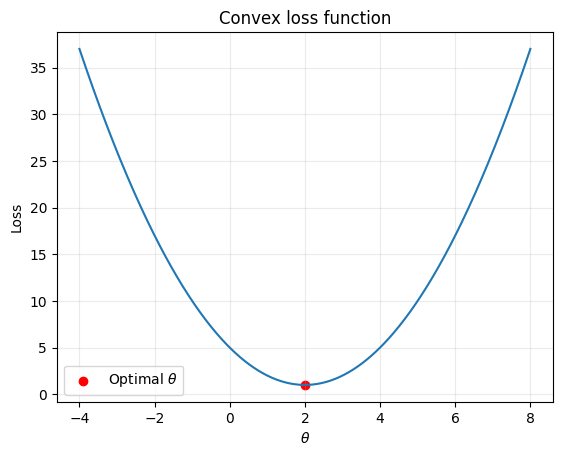

In [2]:
theta = np.linspace(-4, 8, 400)
plt.plot(theta, loss(theta))
plt.scatter(theta_star, loss(theta_star), color="red", label=r"Optimal $\theta$")
plt.xlabel(r"$\theta$"); plt.ylabel("Loss"); plt.title("Convex loss function")
plt.legend(); plt.grid(alpha=0.25); plt.show()

In [3]:
def make_animation(theta0, learning_rate, steps=20):
    history = descent(theta0, learning_rate, steps)
    radius = max(6, 1.2 * np.max(np.abs(history - theta_star)))
    x = np.linspace(theta_star - radius, theta_star + radius, 400)

    fig, ax = plt.subplots()
    ax.plot(x, loss(x))
    ax.scatter(theta_star, loss(theta_star), color="green", label="Optimum")
    trail, = ax.plot([], [], "o--", color="red", lw=1)
    point, = ax.plot([], [], "o", color="red", ms=8)
    label = ax.text(0.03, 0.95, "", transform=ax.transAxes, va="top")
    ax.set(xlabel=r"$\theta$", ylabel="Loss", title="Gradient descent")
    ax.grid(alpha=0.25); ax.legend()

    def update(i):
        trail.set_data(history[:i+1], loss(history[:i+1]))
        point.set_data([history[i]], [loss(history[i])])
        label.set_text(f"Step {i}: theta = {history[i]:.3f}")
        return trail, point, label

    animation = FuncAnimation(fig, update, frames=len(history), interval=250, blit=True)
    return fig, animation

fig, animation = make_animation(theta0=-3.5, learning_rate=0.15)
plt.close(fig)
HTML(animation.to_jshtml())

In [4]:
HTML(r'''
<div id="gd-ui" style="max-width:680px;font-family:sans-serif">
  <label>Initial theta: <b id="t0-value">-3.5</b>
    <input id="t0" type="range" min="-5" max="9" step="0.5" value="-3.5">
  </label><br>
  <label>Learning rate: <b id="lr-value">0.15</b>
    <input id="lr" type="range" min="0.02" max="0.95" step="0.01" value="0.15">
  </label>
  <button id="run-gd">Run animation</button>
  <svg id="gd-plot" viewBox="0 0 640 400" style="width:100%;display:block"></svg>
</div>
<script>
(() => {
  const root = document.getElementById('gd-ui'), svg = root.querySelector('svg');
  const ns = 'http://www.w3.org/2000/svg';
  const X = t => 55 + (t + 6) / 16 * 555, Y = L => 350 - L / 70 * 300;
  const loss = t => (t - 2) ** 2 + 1;
  const add = (tag, a, text='') => {
    const e = document.createElementNS(ns, tag);
    Object.entries(a).forEach(([k,v]) => e.setAttribute(k,v)); e.textContent = text;
    svg.appendChild(e); return e;
  };
  add('line',{x1:55,y1:350,x2:610,y2:350,stroke:'currentColor'});
  add('line',{x1:55,y1:50,x2:55,y2:350,stroke:'currentColor'});
  add('text',{x:330,y:390,'text-anchor':'middle'},'theta');
  add('text',{x:18,y:200,transform:'rotate(-90 18 200)','text-anchor':'middle'},'Loss');
  add('text',{x:320,y:25,'text-anchor':'middle','font-weight':'bold'},'Interactive gradient descent');
  const curve = Array.from({length:201},(_,i) => -6 + 16*i/200);
  add('polyline',{points:curve.map(t=>`${X(t)},${Y(loss(t))}`).join(' '),fill:'none',stroke:'#1f77b4','stroke-width':2});
  add('circle',{cx:X(2),cy:Y(1),r:5,fill:'green'});
  const trail = add('polyline',{fill:'none',stroke:'red','stroke-width':1.5,'stroke-dasharray':'5 4'});
  const point = add('circle',{r:7,fill:'red'});
  const status = add('text',{x:75,y:75},'');
  const t0 = root.querySelector('#t0'), lr = root.querySelector('#lr'); let timer;
  function reset() {
    root.querySelector('#t0-value').textContent = t0.value;
    root.querySelector('#lr-value').textContent = lr.value;
    trail.setAttribute('points',''); point.setAttribute('cx',X(+t0.value));
    point.setAttribute('cy',Y(loss(+t0.value))); status.textContent = 'Step 0';
  }
  function run() {
    clearInterval(timer); let h=[+t0.value], a=+lr.value, i=0;
    for(let k=0;k<20;k++) h.push(h.at(-1)-a*2*(h.at(-1)-2));
    timer=setInterval(() => {
      const shown=h.slice(0,i+1); trail.setAttribute('points',shown.map(t=>`${X(t)},${Y(loss(t))}`).join(' '));
      point.setAttribute('cx',X(h[i])); point.setAttribute('cy',Y(loss(h[i])));
      status.textContent=`Step ${i}: theta = ${h[i].toFixed(3)}`; if(++i===h.length) clearInterval(timer);
    },250);
  }
  t0.oninput=lr.oninput=reset; root.querySelector('#run-gd').onclick=run; reset();
})();
</script>
''')

## Linear regression with two parameters

In [5]:
rng = np.random.default_rng(7)
x_train = np.linspace(0, 4, 30)
y_train = 2 + 1.5*x_train + rng.normal(0, 0.7, x_train.size)
X_train = np.column_stack([np.ones_like(x_train), x_train])
theta_hat = np.linalg.lstsq(X_train, y_train, rcond=None)[0]

def mse(theta):
    return np.mean((X_train @ theta - y_train)**2)

theta0_grid = np.linspace(-4, 4, 70)
theta1_grid = np.linspace(-1.5, 3, 70)
T0, T1 = np.meshgrid(theta0_grid, theta1_grid)
J = np.mean((y_train[:, None, None] - T0 - T1*x_train[:, None, None])**2, axis=0)

### Loss surface

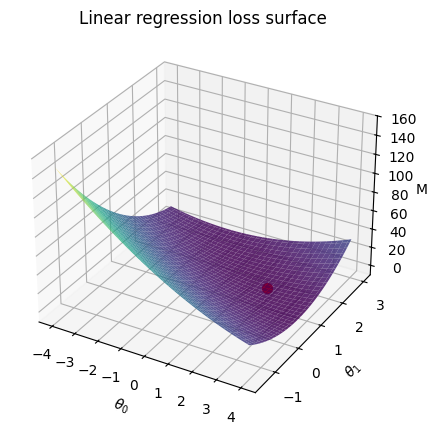

In [6]:
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(projection="3d")
ax.plot_surface(T0, T1, J, cmap="viridis", alpha=0.85)
ax.scatter(theta_hat[0], theta_hat[1], mse(theta_hat), color="red", s=50)
ax.set(xlabel=r"$\theta_0$", ylabel=r"$\theta_1$", zlabel="MSE", title="Linear regression loss surface")
plt.show()

### Batch gradient descent

In [7]:
def batch_gd(theta0=(-3, -1), learning_rate=0.1, steps=80):
    theta, history = np.array(theta0, dtype=float), []
    for _ in range(steps + 1):
        history.append(theta.copy())
        grad = (2/len(X_train)) * X_train.T @ (X_train @ theta - y_train)
        theta -= learning_rate * grad
    return np.array(history)

def regression_animation(path, title, sampled=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.contour(T0, T1, J, levels=22, cmap="viridis")
    ax1.scatter(*theta_hat, marker="*", s=100, color="black", label="Optimum")
    route, = ax1.plot([], [], "o-", color="red", ms=3)
    current, = ax1.plot([], [], "o", color="red", ms=7)
    ax1.set(xlabel=r"$\theta_0$", ylabel=r"$\theta_1$", title="Path on loss contours")
    ax1.legend()

    ax2.scatter(x_train, y_train, s=25, label="Training data")
    x_line = np.array([x_train.min(), x_train.max()])
    fit, = ax2.plot([], [], color="red", lw=2, label="Current fit")
    chosen = ax2.scatter([], [], s=80, facecolors="none", edgecolors="orange")
    status = ax2.text(0.03, 0.95, "", transform=ax2.transAxes, va="top")
    ax2.set(xlabel="x", ylabel="y", title="Evolving line of best fit")
    ax2.legend(loc="lower right"); fig.suptitle(title); fig.tight_layout()

    def update(k):
        theta = path[k]
        route.set_data(path[:k+1, 0], path[:k+1, 1])
        current.set_data([theta[0]], [theta[1]])
        fit.set_data(x_line, theta[0] + theta[1]*x_line)
        status.set_text(f"Step {k}: theta = ({theta[0]:.2f}, {theta[1]:.2f})")
        if sampled is not None and sampled[k] >= 0:
            i = sampled[k]; chosen.set_offsets([[x_train[i], y_train[i]]])
        else:
            chosen.set_offsets(np.empty((0, 2)))
        return route, current, fit, chosen, status

    animation = FuncAnimation(fig, update, frames=len(path), interval=250, blit=True)
    return fig, animation

In [8]:
batch_path = batch_gd()[::4]
fig, batch_animation = regression_animation(batch_path, "Batch gradient descent")
plt.close(fig)
HTML(batch_animation.to_jshtml())

### Stochastic gradient descent

In [9]:
def stochastic_gd(theta0=(-3, -1), learning_rate=0.06, updates=480, keep_every=24):
    rng = np.random.default_rng(2)
    theta = np.array(theta0, dtype=float)
    history, samples = [theta.copy()], [-1]
    for k in range(updates):
        i = rng.integers(len(x_train))
        error = theta[0] + theta[1]*x_train[i] - y_train[i]
        rate = learning_rate / (1 + 0.01*k)
        theta -= rate * 2*error*np.array([1, x_train[i]])
        if (k + 1) % keep_every == 0:
            history.append(theta.copy()); samples.append(i)
    return np.array(history), np.array(samples)

sgd_path, sampled_points = stochastic_gd()
fig, sgd_animation = regression_animation(sgd_path, "Stochastic gradient descent", sampled_points)
plt.close(fig)
HTML(sgd_animation.to_jshtml())